# V3 — Teste de inferência de dados candidatos não vistos

**Esta notícia é candidata para o teste de inferência.** URL → Trafilatura → Titulo + Noticia → TF-IDF e Stacking retreinados sem autoria no 05 → previsão FAKE / REAL → verificação independente → registro e gráficos.

Aqui o modelo permanece congelado: não há retreinamento, calibração ou escolha de limiar. A classificação de padrões textuais não é um veredito factual. **0 = FAKE e 1 = REAL.** Ausência de coincidências exatas não certifica independência por evento/fonte. A seleção da variante após observar a avaliação externa torna esta análise exploratória.

Dependências: pandas, numpy, scikit-learn, joblib, matplotlib, openpyxl, requests, trafilatura e IPython. Se necessário, execute %pip install requests trafilatura openpyxl no kernel. Use a versão de scikit-learn do artefato. Execute as etapas em ordem.


## 01 — Configuração e importação das bibliotecas

Cada execução cria um registro próprio em reports.

In [1]:
from pathlib import Path
import sys, json, hashlib, platform, uuid
import importlib
import importlib.util
import subprocess

# Instala dependencias ausentes no mesmo Python do kernel, antes dos imports.
pacotes_ausentes = [nome for nome in ["trafilatura", "requests", "tzdata"]
                    if importlib.util.find_spec(nome) is None]
if pacotes_ausentes:
    print("Instalando no kernel:", sys.executable, pacotes_ausentes)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *pacotes_ausentes])
    importlib.invalidate_caches()
from time import perf_counter
from datetime import datetime
from zoneinfo import ZoneInfo
from typing import Any, cast
from urllib.parse import urlsplit, urlunsplit
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests, sklearn
try:
    trafilatura = importlib.import_module("trafilatura")
except ModuleNotFoundError as erro_importacao:
    if erro_importacao.name != "trafilatura":
        raise
    # Recupera instalações ausentes no ambiente efetivamente usado pelo kernel.
    subprocess.check_call([sys.executable, "-m", "pip", "install", "trafilatura"])
    import site
    for caminho_site in [*site.getsitepackages(), site.getusersitepackages()]:
        if Path(caminho_site).is_dir():
            site.addsitedir(caminho_site)
    importlib.invalidate_caches()
    trafilatura = importlib.import_module("trafilatura")
print("Trafilatura carregado no kernel:", sys.executable)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import StackingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.validation import check_is_fitted
from IPython.display import Markdown, display
for base in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    module_dir = base / "notebooks/v2_validacao_externa"
    if (module_dir / "pipeline_utils.py").is_file():
        sys.path.insert(0, str(module_dir))
        break
else:
    raise FileNotFoundError("Execute dentro do projeto.")
import ablation_utils
from pipeline_utils import project_root, compose_text, normalize_text, sha256_file, load_manifest, read_partition
ROOT = project_root()
MODEL_PATH = ROOT / "models/v2_stacking_texto_autor_exploratorio/ablacao/sem_autoria.joblib"
DATA_DIR = ROOT / "notebooks/v2_validacao_externa/data/processed/texto_autor_exploratorio_v4"
AGORA = datetime.now(ZoneInfo("America/Sao_Paulo"))
RUN_ID = AGORA.strftime("%Y%m%d_%H%M%S") + "_" + uuid.uuid4().hex[:8]
RUN_DIR = ROOT / "reports/v3_teste_inferencia_dados_nao_vistos" / RUN_ID
RUN_DIR.mkdir(parents=True, exist_ok=False)
LABEL_NAMES = {0: "FAKE", 1: "REAL"}
def hash_texto(texto: str) -> str:
    return hashlib.sha256(texto.encode("utf-8")).hexdigest()


Trafilatura carregado no kernel: c:\Users\LAISA\AppData\Local\Python\pythoncore-3.14-64\python.exe


## 02 — Carregamento do modelo treinado

Carrega o artefato sem_autoria da ablação, sem chamar fit. Confere versão, origem e exclusão efetiva da autoria.

In [2]:
if not MODEL_PATH.is_file():
    raise FileNotFoundError("Execute o retreinamento sem_autoria no notebook 05.")
MODEL_HASH = sha256_file(MODEL_PATH)
artefato = joblib.load(MODEL_PATH)
if not isinstance(artefato, dict) or artefato.get("experimento") != "sem_autoria" or artefato.get("features_ativas") != ["Titulo", "Noticia"]:
    raise ValueError("Esperado artefato retreinado sem autoria.")
if artefato.get("sklearn_version") != sklearn.__version__:
    raise RuntimeError("Use scikit-learn " + str(artefato.get("sklearn_version")))
modelo = cast(Pipeline, artefato["pipeline"])
check_is_fitted(modelo)
if not np.array_equal(np.asarray(modelo.classes_), [0, 1]):
    raise ValueError("Classes incompatíveis.")
manifest = load_manifest(DATA_DIR)
if artefato["manifest"] != manifest:
    raise ValueError("Partições diferentes do treinamento.")
for nome, esperado in manifest["files"].items():
    if sha256_file(DATA_DIR / nome) != esperado:
        raise ValueError(f"Partição alterada: {nome}")
if sha256_file(ROOT / "data/FakeRecogna.xlsx") != manifest["raw_sha256"]:
    raise ValueError("Dataset original alterado.")
stack = cast(StackingClassifier, modelo.named_steps["clf"])
vetorizadores: dict[str, TfidfVectorizer] = {}
for nome_base, estimador in stack.named_estimators_.items():
    estimador = cast(Pipeline, estimador)
    features = cast(Pipeline, estimador.named_steps["features"])
    columns = cast(ColumnTransformer, features.named_steps["columns"])
    transformers_configurados = columns.get_params(deep=False)["transformers"]
    selecoes = {nome: selecao for nome, _, selecao in transformers_configurados}
    if set(selecoes) != {"texto"} or list(selecoes["texto"]) != ["Titulo", "Noticia"]:
        raise ValueError("A base não usa exclusivamente Titulo + Noticia.")
    texto_pipeline = cast(Pipeline, columns.named_transformers_["texto"])
    vetorizadores[str(nome_base)] = cast(TfidfVectorizer, texto_pipeline.named_steps["tfidf"])
print("Modelo congelado:", MODEL_PATH)
print("0 = FAKE; 1 = REAL; features: Titulo + Noticia")


Modelo congelado: C:\Users\LAISA\OneDrive\Documentos\identificador-de-fake-news\models\v2_stacking_texto_autor_exploratorio\ablacao\sem_autoria.joblib
0 = FAKE; 1 = REAL; features: Titulo + Noticia


## 03 — Entrada da URL

URL proposta pelo usuário; continua candidata até concluir a triagem.

In [3]:
URL = "https://veja.abril.com.br/politica/michelle-bolsonaro-chega-ao-fim-da-campanha-com-apenas-uma-doacao/"
if urlsplit(URL).scheme != "https" or not urlsplit(URL).hostname:
    raise ValueError("Informe URL HTTPS válida.")
display(Markdown(f"**Candidata para o teste de inferência:** [Abrir notícia]({URL})"))


**Candidata para o teste de inferência:** [Abrir notícia](https://veja.abril.com.br/politica/michelle-bolsonaro-chega-ao-fim-da-campanha-com-apenas-uma-doacao/)

## 04 — Extração de conteúdo com Trafilatura

Extrai o conteúdo acessível pela URL. Não substitua falhas de extração por um resumo ou texto inventado. Documentação: https://trafilatura.readthedocs.io/en/latest/corefunctions.html

In [5]:
inicio_extracao = perf_counter()
resposta = requests.get(URL, timeout=30, headers={"User-Agent": "PesquisaAcademica-Inferencia/1.0"})
resposta.raise_for_status()
URL_FINAL = resposta.url
HTML_BYTES = resposta.content
(RUN_DIR / "pagina.html").write_bytes(HTML_BYTES)
extraido = trafilatura.bare_extraction(HTML_BYTES, url=URL_FINAL, as_dict=True,
    with_metadata=True, include_comments=False, include_tables=False, favor_precision=True)
if not isinstance(extraido, dict):
    raise RuntimeError("Trafilatura não extraiu conteúdo estruturado.")
titulo = str(extraido.get("title") or "").strip()
noticia = str(extraido.get("text") or "").strip()
tempo_extracao = perf_counter() - inicio_extracao
extracao = {"url": URL, "url_final": URL_FINAL, "Titulo": titulo, "Noticia": noticia,
    "data_publicacao_extraida": str(extraido.get("date") or ""), "data_captura": AGORA.isoformat(), "tempo_extracao_segundos": tempo_extracao,
    "html_sha256": hashlib.sha256(HTML_BYTES).hexdigest()}
(RUN_DIR / "extracao.json").write_text(json.dumps(extracao, ensure_ascii=False, indent=2), encoding="utf-8")
print("Título:", titulo)
print("Data extraída:", extracao["data_publicacao_extraida"])
print("Palavras no corpo:", len(noticia.split()))
print(noticia[:1200])


Título: Michelle Bolsonaro chega ao fim da campanha com apenas uma doação
Data extraída: 2026-10-04
Palavras no corpo: 287
Michelle Bolsonaro chega ao fim da campanha com apenas uma doação
Líder na disputa por uma vaga ao Senado pelo DF, ex-primeira-dama recebeu R$ 100 mil de empresário dono de construtora da capital federal
Líder nas pesquisas de intenção de voto na disputa por uma vaga ao Senado pelo Distrito Federal, Michelle Bolsonaro (PL) recebeu até o momento apenas uma doação financeira ao longo de toda a campanha eleitoral. De acordo com o Tribunal Superior Eleitoral (TSE), a ex-primeira-dama foi agraciada com 100.000 reais – quantia repassada por Simão Sarkis, dono de uma construtora sediada na capital federal.
Ainda segundo o TSE, a campanha de Michelle já havia recebido 3,4 milhões de reais — recursos transferidos pelo PL.
Em relação às despesas, a campanha da ex-primeira-dama declarou à Justiça Eleitoral que os valores já haviam chegado na casa dos 2,2 milhões de reais. Seg

C:\Users\LAISA\AppData\Local\Temp\ipykernel_24176\3518388331.py:7: DeprecationWarning: "as_dict" will be removed, use the .as_dict() method instead
  extraido = trafilatura.bare_extraction(HTML_BYTES, url=URL_FINAL, as_dict=True,


## 05 — Validação dos campos extraídos

Leia a extração e confira o corpo completo no arquivo extracao.json. Ele deve corresponder à reportagem, não a publicidade, resumo de IA ou aviso de assinatura. A inferência interrompe se houver coincidência exata com dados anteriores. A triagem não detecta todos os eventos ou paráfrases.

In [6]:
if not normalize_text(titulo) or not normalize_text(noticia):
    raise ValueError("Título ou corpo vazio.")
if len(noticia.split()) < 80:
    raise ValueError("Corpo curto: confira acesso e extração.")
def chave_url(value: Any) -> str:
    p = urlsplit(str(value).strip())
    return urlunsplit(("https", (p.hostname or "").lower(), p.path.rstrip("/"), "", ""))
corpora = {
    "original": pd.read_excel(ROOT / "data/FakeRecogna.xlsx").fillna(""),
    "treino": read_partition(DATA_DIR / "train.csv"),
    "holdout": read_partition(DATA_DIR / "test_holdout.csv"),
    "externo_anterior": pd.read_csv(ROOT / "data/fakerecogna_extrativo.csv", keep_default_na=False),
}
texto_composto = (titulo + " " + noticia).strip()
triagem: list[dict[str, Any]] = []
for origem, corpus in corpora.items():
    linha = {"corpus": origem, "url": False,
        "titulo": bool(corpus["Titulo"].map(normalize_text).eq(normalize_text(titulo)).any()),
        "corpo": bool(corpus["Noticia"].map(normalize_text).eq(normalize_text(noticia)).any()),
        "texto_combinado": bool(compose_text(corpus).map(normalize_text).eq(normalize_text(texto_composto)).any())}
    if "URL" in corpus:
        linha["url"] = bool(corpus["URL"].map(chave_url).isin([chave_url(URL), chave_url(URL_FINAL)]).any())
    triagem.append(linha)
triagem_df = pd.DataFrame(triagem)
triagem_df.to_csv(RUN_DIR / "triagem_nao_vistos.csv", index=False)
display(triagem_df)
if any(any(linha[c] for c in ["url", "titulo", "corpo", "texto_combinado"]) for linha in triagem):
    raise RuntimeError("Coincidência encontrada: não apresente a notícia como dado não visto.")
status_nao_visto = "candidata_sem_coincidencias_exatas_independencia_por_evento_nao_confirmada"


,corpus,url,titulo,corpo,texto_combinado
0,original,False,False,False,False
1,treino,False,False,False,False
2,holdout,False,False,False,False
3,externo_anterior,False,False,False,False


## 06 — Preparação dos dados para o pipeline

Autor vazio atende apenas ao validador legado. A etapa 02 garante que autoria não entra nas features dos modelos.

In [7]:
entrada = pd.DataFrame({"Titulo": [titulo], "Noticia": [noticia], "Autor": [""]})
entrada.to_csv(RUN_DIR / "entrada_pipeline.csv", index=False)
diagnosticos_vocabulario: list[dict[str, Any]] = []
for nome_base, tfidf in vetorizadores.items():
    termos = list(tfidf.build_analyzer()(texto_composto))
    conhecidos = sum(termo in tfidf.vocabulary_ for termo in termos)
    matriz_texto = tfidf.transform([texto_composto])
    if matriz_texto.getnnz() == 0:
        raise ValueError("Texto sem atributos conhecidos no vocabulário de uma base.")
    diagnosticos_vocabulario.append({"base": nome_base, "termos_analisados": len(termos),
        "termos_conhecidos": conhecidos, "fracao_conhecida": conhecidos / len(termos) if termos else 0.0,
        "atributos_textuais_ativos": int(matriz_texto.getnnz())})
vocabulario_df = pd.DataFrame(diagnosticos_vocabulario)
display(vocabulario_df)


,base,termos_analisados,termos_conhecidos,fracao_conhecida,atributos_textuais_ativos
0,regressao_logistica,561,320,0.57041,172
1,random_forest,561,320,0.57041,172
2,svc,561,320,0.57041,172


## 07 — Inferência com o modelo congelado

O modelo carregado e seus vocabulários não são ajustados com a notícia.

In [8]:
if sha256_file(MODEL_PATH) != MODEL_HASH:
    raise RuntimeError("Artefato alterado antes da inferência.")
inicio_inferencia = perf_counter()
predito = int(np.asarray(modelo.predict(entrada), dtype=int).ravel()[0])
margem_real = float(np.asarray(modelo.decision_function(entrada), dtype=float).ravel()[0])
tempo_predicao_score = perf_counter() - inicio_inferencia
limiar_decisao = 0.0
margem_ao_limiar = margem_real - limiar_decisao
probabilidades: dict[str, float] | None = None
tempo_probabilidade = 0.0
if hasattr(modelo, "predict_proba"):
    inicio_probabilidade = perf_counter()
    proba = np.asarray(modelo.predict_proba(entrada), dtype=float).reshape(1, -1)[0]
    tempo_probabilidade = perf_counter() - inicio_probabilidade
    classes_proba = np.asarray(modelo.classes_, dtype=int).ravel()
    if proba.size != classes_proba.size or not np.isfinite(proba).all() or (proba < 0).any() or (proba > 1).any() or not np.isclose(proba.sum(), 1):
        raise ValueError("Probabilidades inválidas.")
    probabilidades = {LABEL_NAMES[int(classe)]: float(valor) for classe, valor in zip(classes_proba, proba)}
tempo_inferencia = tempo_predicao_score + tempo_probabilidade
# Limiar padrão da Regressão Logística binária do meta-modelo: score > 0 favorece REAL.
if predito != int(margem_real > limiar_decisao):
    raise RuntimeError("Previsão diverge do limiar padrão; confira o meta-modelo.")
if predito not in LABEL_NAMES or not np.isfinite(margem_real):
    raise ValueError("Saída inválida.")
rotulo_previsto = LABEL_NAMES[predito]
if sha256_file(MODEL_PATH) != MODEL_HASH:
    raise RuntimeError("Artefato alterado durante a inferência.")
print("Previsão do modelo:", rotulo_previsto)
print("Margem REAL:", margem_real)


Previsão do modelo: REAL
Margem REAL: 8.602147517210517


## 08 — Apresentação e interpretação da previsão

A margem não é probabilidade ou porcentagem de confiança. Uma notícia não permite estimar F1 ou acurácia agregada. Gráficos descrevem apenas margem e cobertura do vocabulário.

### Previsão: **REAL**

Margem REAL: **8.6021**, não calibrada. A verificação factual é independente.

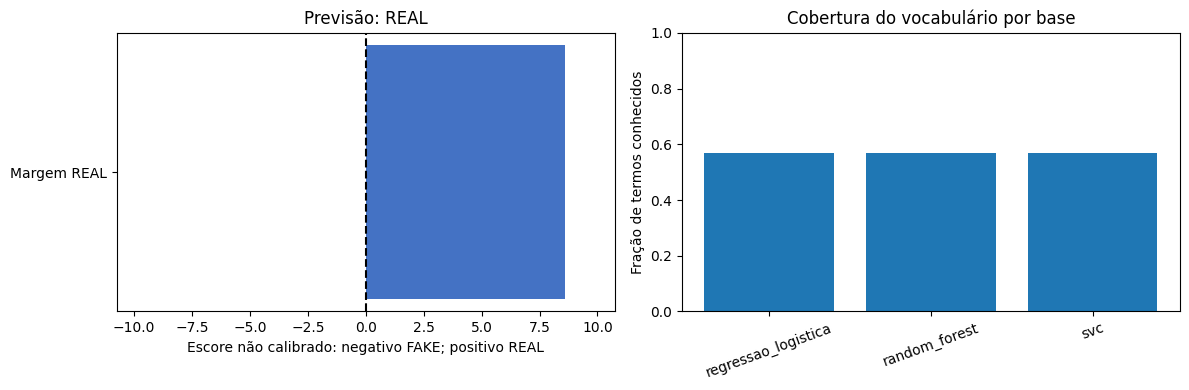

In [9]:
display(Markdown(f"### Previsão: **{rotulo_previsto}**\n\nMargem REAL: **{margem_real:.4f}**, não calibrada. A verificação factual é independente."))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(["Margem REAL"], [margem_real], color="#4472c4" if predito == 1 else "#d97706")
axes[0].axvline(0, color="black", linestyle="--")
limite = max(1.0, abs(margem_real) * 1.25)
axes[0].set_xlim(-limite, limite)
axes[0].set_xlabel("Escore não calibrado: negativo FAKE; positivo REAL")
axes[0].set_title(f"Previsão: {rotulo_previsto}")
axes[1].bar(vocabulario_df["base"].astype(str).to_list(), vocabulario_df["fracao_conhecida"].to_numpy(dtype=float))
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Fração de termos conhecidos")
axes[1].set_title("Cobertura do vocabulário por base")
axes[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
# Gráficos exibidos somente na saída desta célula do notebook.
plt.show()
plt.close(fig)


## 09 — Verificação factual independente

A ficha abaixo registra fontes, evidências e conclusão factual separadamente da previsão do modelo.

Consulte [DivulgaCandContas](https://divulgacandcontas.tse.jus.br/) e [TSE — prestação de contas 2026](https://www.tse.jus.br/eleicoes/eleicoes-2026-content/prestacao-de-contas). Registre o endereço específico, documento, filtro e data de corte. Diferencie doação de pessoa física de transferência partidária. Dados posteriores não refutam automaticamente o retrato anterior. Para pesquisas, procure o levantamento original e seu registro. Revisão humana deve examinar as evidências sem usar a saída do modelo como argumento; outra notícia que copia a VEJA não é evidência independente.

In [10]:
VERIFICACAO: dict[str, Any] = {
    "status_global": "", "revisor": "", "data_verificacao": "", "rotulo_referencia": None,
    "justificativa_global": "",
    "alegacoes": [
        {"alegacao": "Quantidade e valor de doações individuais no período descrito", "status": "", "fonte_primaria_url": "", "data_corte": "", "evidencia": ""},
        {"alegacao": "Transferências partidárias e despesas no período descrito", "status": "", "fonte_primaria_url": "", "data_corte": "", "evidencia": ""},
        {"alegacao": "Posição nas pesquisas citadas", "status": "", "fonte_primaria_url": "", "data_corte": "", "evidencia": ""},
    ],
    "fontes_para_consulta": ["https://divulgacandcontas.tse.jus.br/", "https://www.tse.jus.br/eleicoes/eleicoes-2026-content/prestacao-de-contas"],
}
# Preencha após revisão: None significa ausência de referência factual.
if VERIFICACAO["rotulo_referencia"] not in [None, 0, 1]:
    raise ValueError("Referência deve ser None, 0 = FAKE ou 1 = REAL.")
if VERIFICACAO["rotulo_referencia"] is not None:
    if VERIFICACAO["status_global"] not in ["confirmado", "refutado"] or not all(VERIFICACAO[c] for c in ["revisor", "data_verificacao", "justificativa_global"]):
        raise ValueError("Referência exige revisão documentada.")
    if not any(a["fonte_primaria_url"] and a["evidencia"] for a in VERIFICACAO["alegacoes"]):
        raise ValueError("Registre fonte e evidência.")
display(pd.DataFrame(VERIFICACAO["alegacoes"]))
if VERIFICACAO["status_global"]:
    print("Verificação factual:", VERIFICACAO["status_global"])


,alegacao,status,fonte_primaria_url,data_corte,evidencia
0,Quantidade e valor de doações individuais no p...,,,,
1,Transferências partidárias e despesas no perío...,,,,
2,Posição nas pesquisas citadas,,,,


## 10 — Registro e documentação da inferência

Preserva a captura, extração, entrada, triagem, versões, hashes, previsão e ficha factual em uma pasta por execução. Os gráficos aparecem somente no próprio notebook; salve o notebook após executar para preservar essas saídas.

In [11]:
# Recupera resultados reais caso a célula de inferência atualizada não tenha sido executada.
if any(nome not in globals() for nome in ["probabilidades","tempo_inferencia","tempo_predicao_score","tempo_probabilidade","limiar_decisao","margem_ao_limiar"]):
    from time import perf_counter
    if sha256_file(MODEL_PATH) != MODEL_HASH:
        raise RuntimeError("Artefato alterado antes da inferência.")
    inicio_inferencia = perf_counter()
    predito = int(np.asarray(modelo.predict(entrada), dtype=int).ravel()[0])
    margem_real = float(np.asarray(modelo.decision_function(entrada), dtype=float).ravel()[0])
    tempo_predicao_score = perf_counter() - inicio_inferencia
    limiar_decisao = 0.0
    margem_ao_limiar = margem_real - limiar_decisao
    probabilidades: dict[str, float] | None = None
    tempo_probabilidade = 0.0
    if hasattr(modelo, "predict_proba"):
        inicio_probabilidade = perf_counter()
        proba = np.asarray(modelo.predict_proba(entrada), dtype=float).reshape(1, -1)[0]
        tempo_probabilidade = perf_counter() - inicio_probabilidade
        classes_proba = np.asarray(modelo.classes_, dtype=int).ravel()
        if proba.size != classes_proba.size or not np.isfinite(proba).all() or (proba < 0).any() or (proba > 1).any() or not np.isclose(proba.sum(), 1):
            raise ValueError("Probabilidades inválidas.")
        probabilidades = {LABEL_NAMES[int(classe)]: float(valor) for classe, valor in zip(classes_proba, proba)}
    tempo_inferencia = tempo_predicao_score + tempo_probabilidade
    # Limiar padrão da Regressão Logística binária do meta-modelo: score > 0 favorece REAL.
    if predito != int(margem_real > limiar_decisao):
        raise RuntimeError("Previsão diverge do limiar padrão; confira o meta-modelo.")
    if predito not in LABEL_NAMES or not np.isfinite(margem_real):
        raise ValueError("Saída inválida.")
    rotulo_previsto = LABEL_NAMES[predito]
    if sha256_file(MODEL_PATH) != MODEL_HASH:
        raise RuntimeError("Artefato alterado durante a inferência.")
    print("Previsão do modelo:", rotulo_previsto)
    print("Margem REAL:", margem_real)
if "tempo_extracao" not in globals():
    from time import perf_counter
    inicio_extracao = perf_counter()
    resposta = requests.get(URL, timeout=30, headers={"User-Agent": "PesquisaAcademica-Inferencia/1.0"})
    resposta.raise_for_status()
    URL_FINAL = resposta.url
    HTML_BYTES = resposta.content
    (RUN_DIR / "pagina.html").write_bytes(HTML_BYTES)
    extraido = trafilatura.bare_extraction(HTML_BYTES, url=URL_FINAL, as_dict=True,
        with_metadata=True, include_comments=False, include_tables=False, favor_precision=True)
    if not isinstance(extraido, dict):
        raise RuntimeError("Trafilatura não extraiu conteúdo estruturado.")
    titulo = str(extraido.get("title") or "").strip()
    noticia = str(extraido.get("text") or "").strip()
    tempo_extracao = perf_counter() - inicio_extracao
    extracao = {"url": URL, "url_final": URL_FINAL, "Titulo": titulo, "Noticia": noticia,
        "data_publicacao_extraida": str(extraido.get("date") or ""), "data_captura": AGORA.isoformat(), "tempo_extracao_segundos": tempo_extracao,
        "html_sha256": hashlib.sha256(HTML_BYTES).hexdigest()}
    (RUN_DIR / "extracao.json").write_text(json.dumps(extracao, ensure_ascii=False, indent=2), encoding="utf-8")
    print("Título:", titulo)
    print("Data extraída:", extracao["data_publicacao_extraida"])
    print("Palavras no corpo:", len(noticia.split()))
    print(noticia[:1200])

registro = {
    "run_id": RUN_ID, "data_hora": AGORA.isoformat(), "timezone": "America/Sao_Paulo",
    "url": URL, "url_final": URL_FINAL, "data_publicacao_extraida": extracao["data_publicacao_extraida"],
    "status_nao_visto": status_nao_visto, "triagem": triagem,
    "modelo": str(MODEL_PATH.relative_to(ROOT)), "modelo_sha256": MODEL_HASH,
    "features_efetivas": ["Titulo", "Noticia"], "manifest_treinamento": manifest,
    "titulo_sha256": hash_texto(titulo), "corpo_sha256": hash_texto(noticia),
    "texto_sha256": hash_texto(texto_composto), "html_sha256": extracao["html_sha256"],
    "predito": predito, "previsao": rotulo_previsto,
    "label_names": LABEL_NAMES, "margem_real": margem_real, "probabilidade_calibrada": None,
    "probabilidades_estimadas": probabilidades, "limiar_decisao": limiar_decisao,
    "distancia_ao_limiar_em_score": abs(margem_ao_limiar),
    "tempo_extracao_segundos": tempo_extracao, "tempo_inferencia_segundos": tempo_inferencia,
    "tempo_predicao_score_segundos": tempo_predicao_score, "tempo_probabilidade_segundos": tempo_probabilidade,
    "verificacao_factual": VERIFICACAO,
    "concordancia_com_referencia": predito == VERIFICACAO["rotulo_referencia"] if VERIFICACAO["rotulo_referencia"] is not None else None,
    "versoes": {"python": platform.python_version(), "sklearn": sklearn.__version__, "pandas": pd.__version__, "trafilatura": getattr(trafilatura, "__version__", "desconhecida")},
    "limitacoes": ["Uma notícia; sem métricas agregadas", "Margem não calibrada", "Independência por evento não confirmada", "Variante escolhida após avaliar externo"],
}
(RUN_DIR / "registro.json").write_text(json.dumps(registro, ensure_ascii=False, indent=2), encoding="utf-8")
(RUN_DIR / "verificacao_factual.json").write_text(json.dumps(VERIFICACAO, ensure_ascii=False, indent=2), encoding="utf-8")
vocabulario_df.to_csv(RUN_DIR / "cobertura_vocabulario.csv", index=False)
pd.DataFrame([{"url": URL, "predito": predito, "previsao": rotulo_previsto, "margem_real": margem_real, "verificacao": VERIFICACAO["status_global"]}]).to_csv(RUN_DIR / "resultado.csv", index=False)
resumo = (f"# Inferência — {RUN_ID}\n\nCandidata para o teste de inferência: {URL}\n\n"
    f"Modelo retreinado sem autoria: Título + Notícia. Previsão: **{rotulo_previsto}**; margem REAL {margem_real:.4f}, não calibrada.\n\n"
    f"Triagem: {status_nao_visto}.\n\n"
    "A execução não certifica a veracidade da notícia ou generalização do modelo. Consulte registro.json e os gráficos exibidos neste notebook.\n")
(RUN_DIR / "relatorio.md").write_text(resumo, encoding="utf-8")
display(Markdown(resumo))
print("Experimento registrado em:", RUN_DIR)


# Inferência — 20261009_164940_7ab2c05f

Candidata para o teste de inferência: https://veja.abril.com.br/politica/michelle-bolsonaro-chega-ao-fim-da-campanha-com-apenas-uma-doacao/

Modelo retreinado sem autoria: Título + Notícia. Previsão: **REAL**; margem REAL 8.6021, não calibrada.

Triagem: candidata_sem_coincidencias_exatas_independencia_por_evento_nao_confirmada.

A execução não certifica a veracidade da notícia ou generalização do modelo. Consulte registro.json e os gráficos exibidos neste notebook.


Experimento registrado em: C:\Users\LAISA\OneDrive\Documentos\identificador-de-fake-news\reports\v3_teste_inferencia_dados_nao_vistos\20261009_164940_7ab2c05f


## 11 — Conclusão do teste de inferência e métricas

A tabela distingue classe, score, distância ao limiar, probabilidades estimadas, tempos e características da extração. O score é a margem assinada da classe REAL. A distância ao limiar é o valor absoluto dessa margem, em unidades de score; não é uma probabilidade nem uma distância geométrica ao hiperplano.

As probabilidades de predict_proba são estimativas do meta-modelo, sem calibração externa validada. O tempo de extração inclui download e Trafilatura. O tempo de inferência inclui predict, decision_function e predict_proba, quando disponível; essas chamadas repetem parte do processamento.

Completude estrutural significa que título e corpo foram recuperados e passaram pelas validações. Isso não confirma, por si só, que todo o conteúdo editorial da página foi extraído. O veredito factual e a concordância dependem de evidências registradas na etapa 09. Os gráficos permanecem somente nas saídas deste notebook.


,Métrica,Resultado,Prioridade
0,Classe prevista,1,Essencial
1,Resultado FAKE ou REAL,REAL,Essencial
2,Score de decisão REAL,8.602148,Essencial
3,Intensidade do sinal |score|,8.602148,Essencial
4,Margem assinada ao limiar,8.602148,Alta
5,Distância ao limiar em score,8.602148,Alta
6,Probabilidade estimada da classe prevista,99.98% (sem calibração externa validada),Alta
7,Limiar de decisão,0.0,Alta
8,Tempo de inferência,0.186829 s,Essencial
9,Tempo de extração,0.378160 s,Alta


## Conclusão do teste de inferência

O pipeline completou as validações, a extração, a preparação e a inferência com o artefato preservado. Isso confirma o funcionamento técnico nesta execução.

**Como o modelo decide:** o título e o corpo são combinados; cada base aplica seu TF-IDF aprendido no treino, sem autoria. As bases Regressão Logística, Random Forest e LinearSVC geram as entradas do meta-modelo de Regressão Logística, que determina a classe final.

Nesta notícia, a classe prevista foi **REAL (1)**, com score REAL **8.602148**, limiar **0.0** e distância ao limiar **8.602148**. Score positivo favorece REAL; score negativo favorece FAKE. O valor absoluto descreve a intensidade do sinal, sem medir certeza factual. Probabilidade estimada da classe prevista: **99.98% (sem calibração externa validada)**.

A extração levou **0.378160 s** e as chamadas de inferência **0.186829 s**. Foram analisadas **298 palavras e 1843 caracteres** de título e corpo. A recuperação dos campos passou pelas validações estruturais; a integridade editorial completa não foi certificada automaticamente.

**Não é possível concluir se a previsão corresponde à realidade:** não há um rótulo factual sustentado por evidências registradas. A previsão do modelo não estabelece a veracidade da notícia.

A triagem não encontrou coincidências exatas com os corpora consultados; independência por evento não foi estabelecida. Este é um teste individual e exploratório; não permite estimar acurácia ou F1 de generalização.


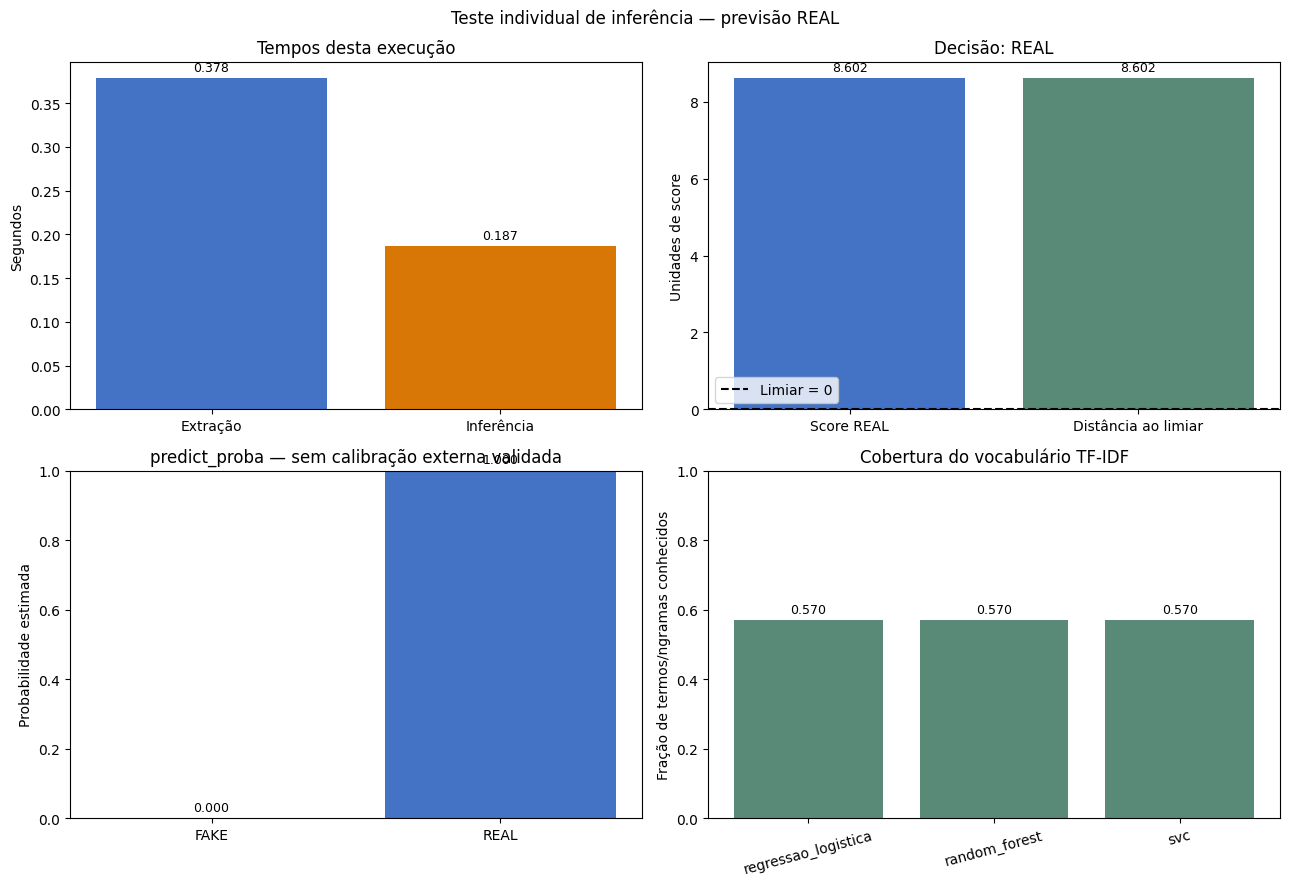

In [12]:
# Recupera resultados reais caso a célula de inferência atualizada não tenha sido executada.
if any(nome not in globals() for nome in ["probabilidades","tempo_inferencia","tempo_predicao_score","tempo_probabilidade","limiar_decisao","margem_ao_limiar"]):
    from time import perf_counter
    if sha256_file(MODEL_PATH) != MODEL_HASH:
        raise RuntimeError("Artefato alterado antes da inferência.")
    inicio_inferencia = perf_counter()
    predito = int(np.asarray(modelo.predict(entrada), dtype=int).ravel()[0])
    margem_real = float(np.asarray(modelo.decision_function(entrada), dtype=float).ravel()[0])
    tempo_predicao_score = perf_counter() - inicio_inferencia
    limiar_decisao = 0.0
    margem_ao_limiar = margem_real - limiar_decisao
    probabilidades: dict[str, float] | None = None
    tempo_probabilidade = 0.0
    if hasattr(modelo, "predict_proba"):
        inicio_probabilidade = perf_counter()
        proba = np.asarray(modelo.predict_proba(entrada), dtype=float).reshape(1, -1)[0]
        tempo_probabilidade = perf_counter() - inicio_probabilidade
        classes_proba = np.asarray(modelo.classes_, dtype=int).ravel()
        if proba.size != classes_proba.size or not np.isfinite(proba).all() or (proba < 0).any() or (proba > 1).any() or not np.isclose(proba.sum(), 1):
            raise ValueError("Probabilidades inválidas.")
        probabilidades = {LABEL_NAMES[int(classe)]: float(valor) for classe, valor in zip(classes_proba, proba)}
    tempo_inferencia = tempo_predicao_score + tempo_probabilidade
    # Limiar padrão da Regressão Logística binária do meta-modelo: score > 0 favorece REAL.
    if predito != int(margem_real > limiar_decisao):
        raise RuntimeError("Previsão diverge do limiar padrão; confira o meta-modelo.")
    if predito not in LABEL_NAMES or not np.isfinite(margem_real):
        raise ValueError("Saída inválida.")
    rotulo_previsto = LABEL_NAMES[predito]
    if sha256_file(MODEL_PATH) != MODEL_HASH:
        raise RuntimeError("Artefato alterado durante a inferência.")
    print("Previsão do modelo:", rotulo_previsto)
    print("Margem REAL:", margem_real)
if "tempo_extracao" not in globals():
    from time import perf_counter
    inicio_extracao = perf_counter()
    resposta = requests.get(URL, timeout=30, headers={"User-Agent": "PesquisaAcademica-Inferencia/1.0"})
    resposta.raise_for_status()
    URL_FINAL = resposta.url
    HTML_BYTES = resposta.content
    (RUN_DIR / "pagina.html").write_bytes(HTML_BYTES)
    extraido = trafilatura.bare_extraction(HTML_BYTES, url=URL_FINAL, as_dict=True,
        with_metadata=True, include_comments=False, include_tables=False, favor_precision=True)
    if not isinstance(extraido, dict):
        raise RuntimeError("Trafilatura não extraiu conteúdo estruturado.")
    titulo = str(extraido.get("title") or "").strip()
    noticia = str(extraido.get("text") or "").strip()
    tempo_extracao = perf_counter() - inicio_extracao
    extracao = {"url": URL, "url_final": URL_FINAL, "Titulo": titulo, "Noticia": noticia,
        "data_publicacao_extraida": str(extraido.get("date") or ""), "data_captura": AGORA.isoformat(), "tempo_extracao_segundos": tempo_extracao,
        "html_sha256": hashlib.sha256(HTML_BYTES).hexdigest()}
    (RUN_DIR / "extracao.json").write_text(json.dumps(extracao, ensure_ascii=False, indent=2), encoding="utf-8")
    print("Título:", titulo)
    print("Data extraída:", extracao["data_publicacao_extraida"])
    print("Palavras no corpo:", len(noticia.split()))
    print(noticia[:1200])

# Execute após as etapas 04 a 10 para obter tempos e resultados da mesma execução.
referencia = VERIFICACAO["rotulo_referencia"]
referencia_documentada = (
    referencia in [0, 1]
    and VERIFICACAO["status_global"] in ["confirmado", "refutado"]
    and all(VERIFICACAO[c] for c in ["revisor", "data_verificacao", "justificativa_global"])
    and any(a["fonte_primaria_url"] and a["evidencia"] for a in VERIFICACAO["alegacoes"])
)
veredito = LABEL_NAMES[int(referencia)] if referencia_documentada else "Não estabelecido pelas evidências registradas"
concordancia = ("SIM" if predito == referencia else "NÃO") if referencia_documentada else "Não avaliável sem referência factual"
completude_estrutural = bool(normalize_text(titulo) and normalize_text(noticia) and len(noticia.split()) >= 80)
modelo_preservado = sha256_file(MODEL_PATH) == MODEL_HASH
pipeline_ok = completude_estrutural and modelo_preservado and np.isfinite(margem_real) and predito in LABEL_NAMES
n_palavras = len(texto_composto.split())
n_caracteres = len(texto_composto)
probabilidade_classe = probabilidades[rotulo_previsto] if probabilidades is not None else None
texto_probabilidade = f"{100 * probabilidade_classe:.2f}% (sem calibração externa validada)" if probabilidade_classe is not None else "predict_proba indisponível"
linhas_metricas = [
    {"Métrica": "Classe prevista", "Resultado": predito, "Prioridade": "Essencial"},
    {"Métrica": "Resultado FAKE ou REAL", "Resultado": rotulo_previsto, "Prioridade": "Essencial"},
    {"Métrica": "Score de decisão REAL", "Resultado": f"{margem_real:.6f}", "Prioridade": "Essencial"},
    {"Métrica": "Intensidade do sinal |score|", "Resultado": f"{abs(margem_real):.6f}", "Prioridade": "Essencial"},
    {"Métrica": "Margem assinada ao limiar", "Resultado": f"{margem_ao_limiar:.6f}", "Prioridade": "Alta"},
    {"Métrica": "Distância ao limiar em score", "Resultado": f"{abs(margem_ao_limiar):.6f}", "Prioridade": "Alta"},
    {"Métrica": "Probabilidade estimada da classe prevista", "Resultado": texto_probabilidade, "Prioridade": "Alta"},
    {"Métrica": "Limiar de decisão", "Resultado": limiar_decisao, "Prioridade": "Alta"},
    {"Métrica": "Tempo de inferência", "Resultado": f"{tempo_inferencia:.6f} s", "Prioridade": "Essencial"},
    {"Métrica": "Tempo de extração", "Resultado": f"{tempo_extracao:.6f} s", "Prioridade": "Alta"},
    {"Métrica": "Completude estrutural", "Resultado": "Título e corpo recuperados; validações aprovadas" if completude_estrutural else "Campos insuficientes", "Prioridade": "Essencial"},
    {"Métrica": "Tamanho do texto analisado", "Resultado": f"{n_palavras} palavras; {n_caracteres} caracteres", "Prioridade": "Alta"},
    {"Métrica": "Veredito independente", "Resultado": veredito, "Prioridade": "Essencial para avaliar acerto"},
    {"Métrica": "Concordância com o veredito", "Resultado": concordancia, "Prioridade": "Essencial para avaliar acerto"},
]
for item in vocabulario_df.to_dict(orient="records"):
    linhas_metricas.append({"Métrica": f"Cobertura TF-IDF — {item['base']}",
        "Resultado": f"{100 * float(item['fracao_conhecida']):.2f}% dos termos/ngramas; {int(item['atributos_textuais_ativos'])} atributos ativos",
        "Prioridade": "Complementar"})
metricas_finais = pd.DataFrame(linhas_metricas)
display(metricas_finais)
if pipeline_ok:
    funcionamento = "O pipeline completou as validações, a extração, a preparação e a inferência com o artefato preservado. Isso confirma o funcionamento técnico nesta execução."
else:
    funcionamento = "As verificações técnicas desta execução não foram integralmente satisfeitas."
if referencia_documentada:
    resultado_factual = f"O veredito independente registrado é **{veredito}**. A previsão **{'corresponde' if predito == referencia else 'não corresponde'}** a esse veredito. Evidências e justificativa constam da etapa 09."
else:
    resultado_factual = "**Não é possível concluir se a previsão corresponde à realidade:** não há um rótulo factual sustentado por evidências registradas. A previsão do modelo não estabelece a veracidade da notícia."
conclusao_final = (
    "## Conclusão do teste de inferência\n\n"
    f"{funcionamento}\n\n"
    "**Como o modelo decide:** o título e o corpo são combinados; cada base aplica seu TF-IDF aprendido no treino, "
    "sem autoria. As bases Regressão Logística, Random Forest e LinearSVC geram as entradas do meta-modelo de "
    "Regressão Logística, que determina a classe final.\n\n"
    f"Nesta notícia, a classe prevista foi **{rotulo_previsto} ({predito})**, com score REAL **{margem_real:.6f}**, "
    f"limiar **{limiar_decisao:.1f}** e distância ao limiar **{abs(margem_ao_limiar):.6f}**. "
    "Score positivo favorece REAL; score negativo favorece FAKE. O valor absoluto descreve a intensidade do sinal, sem medir certeza factual. "
    f"Probabilidade estimada da classe prevista: **{texto_probabilidade}**.\n\n"
    f"A extração levou **{tempo_extracao:.6f} s** e as chamadas de inferência **{tempo_inferencia:.6f} s**. "
    f"Foram analisadas **{n_palavras} palavras e {n_caracteres} caracteres** de título e corpo. "
    "A recuperação dos campos passou pelas validações estruturais; a integridade editorial completa não foi certificada automaticamente.\n\n"
    f"{resultado_factual}\n\n"
    "A triagem não encontrou coincidências exatas com os corpora consultados; independência por evento não foi estabelecida. "
    "Este é um teste individual e exploratório; não permite estimar acurácia ou F1 de generalização.\n"
)
display(Markdown(conclusao_final))
metricas_finais.to_csv(RUN_DIR / "metricas_conclusao.csv", index=False)
(RUN_DIR / "conclusao_inferencia.md").write_text(conclusao_final, encoding="utf-8")
registro.update({"pipeline_validacoes_tecnicas_ok": bool(pipeline_ok),
    "completude_estrutural": completude_estrutural, "palavras_analisadas": n_palavras,
    "caracteres_analisados": n_caracteres, "veredito_documentado": bool(referencia_documentada),
    "concordancia_com_referencia": bool(predito == referencia) if referencia_documentada else None})
(RUN_DIR / "registro.json").write_text(json.dumps(registro, ensure_ascii=False, indent=2), encoding="utf-8")
# Painéis de colunas com unidades separadas: sem misturar segundos, scores e probabilidades.
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0, 0].bar(["Extração", "Inferência"], [tempo_extracao, tempo_inferencia], color=["#4472c4", "#d97706"])
axes[0, 0].set_ylabel("Segundos")
axes[0, 0].set_title("Tempos desta execução")
axes[0, 1].bar(["Score REAL", "Distância ao limiar"], [margem_real, abs(margem_ao_limiar)], color=["#4472c4", "#598a78"])
axes[0, 1].axhline(limiar_decisao, color="black", linestyle="--", label="Limiar = 0")
axes[0, 1].set_ylabel("Unidades de score")
axes[0, 1].set_title(f"Decisão: {rotulo_previsto}")
axes[0, 1].legend()
if probabilidades is not None:
    axes[1, 0].bar(list(probabilidades), list(probabilidades.values()), color=["#d97706", "#4472c4"])
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].set_ylabel("Probabilidade estimada")
    axes[1, 0].set_title("predict_proba — sem calibração externa validada")
else:
    axes[1, 0].text(0.5, 0.5, "predict_proba indisponível", ha="center", va="center")
    axes[1, 0].set_axis_off()
axes[1, 1].bar(vocabulario_df["base"].astype(str).to_list(), vocabulario_df["fracao_conhecida"].to_numpy(dtype=float), color="#598a78")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_ylabel("Fração de termos/ngramas conhecidos")
axes[1, 1].set_title("Cobertura do vocabulário TF-IDF")
axes[1, 1].tick_params(axis="x", rotation=15)
for ax in np.asarray(axes).ravel():
    if ax.axison:
        for container in ax.containers:
            ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)
fig.suptitle(f"Teste individual de inferência — previsão {rotulo_previsto}")
fig.tight_layout()
plt.show()
plt.close(fig)
